# Лабораторная работа 2 (Вариат 13)
**Тема.** АППРОКСИМАЦИЯ ФУНКЦИЙ

Требуется аппроксимировать заданную исходную функцию $f(x)$ многочленом на интервале $[a, b]$. Задано количество неизвестных параметров $n$, вид аппроксимации и $m$ – количество точек, в которых задана функция. Таблица исходной функции $ y_i=f(x_i) $ вычисляется в точках $ x_i = a + \frac{(i - 1) \cdot (b - a)}{m-1}, i=1, m $. Используя полученную таблицу $(x_i, y_i)$, требуется вычислить значения функций $ f(x_j), \phi(x_j, c) $ и погрешность $d(x_j) = f(x_j)-\phi(x_j, c)$ в точках $x_j=a+ \frac{(j-1) \cdot (b-a)}{20}; j=1, 21$, построить графики и проанализировать качество полученной аппроксимации.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = 1
b = 7
m = 11
n = 5

def f(x):
    return np.sin(x)**2 - 3 * np.cos(x)

По условию варианта необходимо использовать метод наименьших квадратов.

Формирование узлов аппроксимации ($m$ точек)

In [2]:
x_i = np.linspace(a, b, m)
y_i = f(x_i)

Аппроксимация многочленом степени $n-1$ (в данном случае 4-й степени)

In [3]:
coeffs = np.polyfit(x_i, y_i, n - 1)
phi = np.poly1d(coeffs)

Вычисление значений в контрольной точке при $j = 21$

In [4]:
x_j = np.linspace(a, b, 21)
f_j = f(x_j)
phi_j = phi(x_j)
d_j = f_j - phi_j

Выведем таблицу результатов

In [5]:
print(f"{'x_j':>10} | {'f(x_j)':>10} | {'phi(x_j)':>10} | {'d(x_j)':>10}")
print("-" * 50)
for i in range(len(x_j)):
    print(f"{x_j[i]:10.4f} | {f_j[i]:10.4f} | {phi_j[i]:10.4f} | {d_j[i]:10.4f}")

       x_j |     f(x_j) |   phi(x_j) |     d(x_j)
--------------------------------------------------
    1.0000 |    -0.9128 |    -0.7964 |    -0.1164
    1.3000 |     0.1259 |     0.0357 |     0.0902
    1.6000 |     1.0867 |     0.8707 |     0.2161
    1.9000 |     1.8654 |     1.6459 |     0.2194
    2.2000 |     2.4192 |     2.3100 |     0.1091
    2.5000 |     2.7616 |     2.8223 |    -0.0607
    2.8000 |     2.9389 |     3.1532 |    -0.2143
    3.1000 |     2.9991 |     3.2838 |    -0.2847
    3.4000 |     2.9657 |     3.2063 |    -0.2407
    3.7000 |     2.8250 |     2.9239 |    -0.0989
    4.0000 |     2.5337 |     2.4506 |     0.0831
    4.3000 |     2.0418 |     1.8112 |     0.2305
    4.6000 |     1.3239 |     1.0417 |     0.2822
    4.9000 |     0.4057 |     0.1889 |     0.2168
    5.2000 |    -0.6251 |    -0.6897 |     0.0646
    5.5000 |    -1.6282 |    -1.5252 |    -0.1030
    5.8000 |    -2.4407 |    -2.2382 |    -0.2025
    6.1000 |    -2.9166 |    -2.7381 |    -0.1785

Построим график функции и аппроксимации

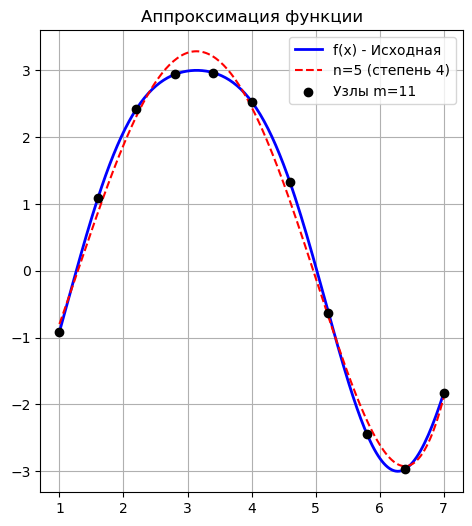

In [6]:
x_plot = np.linspace(a, b, 200)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(x_plot, f(x_plot), label='f(x) - Исходная', color='blue', lw=2)
plt.plot(x_plot, phi(x_plot), '--', label=f'n={n} (степень {n-1})', color='red')
plt.scatter(x_i, y_i, color='black', zorder=5, label='Узлы m=11')
plt.title('Аппроксимация функции')
plt.legend()
plt.grid(True)

Построим график погрешности

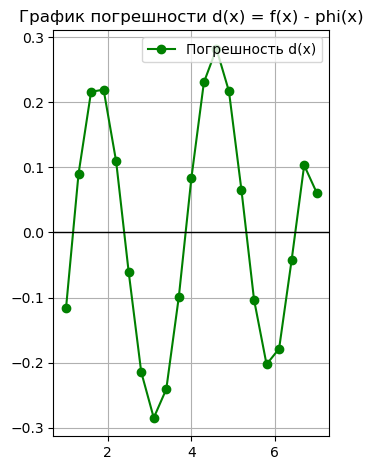

In [7]:
plt.subplot(1, 2, 2)
plt.plot(x_j, d_j, 'o-', color='green', label='Погрешность d(x)')
plt.axhline(0, color='black', lw=1)
plt.title('График погрешности d(x) = f(x) - phi(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()